# 241. Different Ways to Add Parentheses
https://leetcode.com/problems/different-ways-to-add-parentheses/

## Complexity Comparison

| Approach | Time | Space | Description |
|----------|------|-------|-------------|
| **Divide and Conquer** | **O(Catalan(n))** | **O(Catalan(n))** | **Split at each operator, combine results** |
| Memoized D&C | O(Catalan(n)) | O(Catalan(n)) | Cache subproblems by substring |

## Methodology

We use **divide and conquer**. For each operator in the expression, we split into left and right sub-expressions, recursively compute all possible results for each side, and combine them using the operator. Base case: if the expression is a pure number, return it as the only result. This naturally enumerates all possible parenthesizations. The number of results follows the Catalan numbers.

## Solutions

### C#

In [ ]:
// 241. Different Ways to Add Parentheses
// Time: O(Catalan(n)) | Space: O(Catalan(n))
public class Solution {
    public IList<int> DiffWaysToCompute(string expression) {
        var result = new List<int>();
        
        for (int i = 0; i < expression.Length; i++) {
            char c = expression[i];
            if (c == '+' || c == '-' || c == '*') {
                var left = DiffWaysToCompute(expression.Substring(0, i));
                var right = DiffWaysToCompute(expression.Substring(i + 1));
                
                foreach (int l in left) {
                    foreach (int r in right) {
                        if (c == '+') result.Add(l + r);
                        else if (c == '-') result.Add(l - r);
                        else result.Add(l * r);
                    }
                }
            }
        }
        
        if (result.Count == 0)
            result.Add(int.Parse(expression));
        
        return result;
    }
}

### Python

In [ ]:
# 241. Different Ways to Add Parentheses
# Time: O(Catalan(n)) | Space: O(Catalan(n))
class Solution:
    def diffWaysToCompute(self, expression: str) -> list[int]:
        result = []
        
        for i, c in enumerate(expression):
            if c in '+-*':
                left = self.diffWaysToCompute(expression[:i])
                right = self.diffWaysToCompute(expression[i + 1:])
                
                for l in left:
                    for r in right:
                        if c == '+': result.append(l + r)
                        elif c == '-': result.append(l - r)
                        else: result.append(l * r)
        
        if not result:
            result.append(int(expression))
        
        return result

### Go

In [ ]:
// 241. Different Ways to Add Parentheses
// Time: O(Catalan(n)) | Space: O(Catalan(n))
import "strconv"

func diffWaysToCompute(expression string) []int {
    var result []int
    
    for i, c := range expression {
        if c == '+' || c == '-' || c == '*' {
            left := diffWaysToCompute(expression[:i])
            right := diffWaysToCompute(expression[i+1:])
            
            for _, l := range left {
                for _, r := range right {
                    switch c {
                    case '+':
                        result = append(result, l+r)
                    case '-':
                        result = append(result, l-r)
                    case '*':
                        result = append(result, l*r)
                    }
                }
            }
        }
    }
    
    if len(result) == 0 {
        num, _ := strconv.Atoi(expression)
        result = append(result, num)
    }
    
    return result
}

### Rust

In [ ]:
// 241. Different Ways to Add Parentheses
// Time: O(Catalan(n)) | Space: O(Catalan(n))
impl Solution {
    pub fn diff_ways_to_compute(expression: String) -> Vec<i32> {
        let mut result = Vec::new();
        let chars: Vec<char> = expression.chars().collect();
        
        for (i, &c) in chars.iter().enumerate() {
            if c == '+' || c == '-' || c == '*' {
                let left = Self::diff_ways_to_compute(expression[..i].to_string());
                let right = Self::diff_ways_to_compute(expression[i+1..].to_string());
                
                for &l in &left {
                    for &r in &right {
                        result.push(match c {
                            '+' => l + r,
                            '-' => l - r,
                            _ => l * r,
                        });
                    }
                }
            }
        }
        
        if result.is_empty() {
            result.push(expression.parse().unwrap());
        }
        
        result
    }
}

## Example Scenarios

### 1. Common Case — Two Operators
**Input:** `"2-1-1"`

Split at first `-`: `(2)-(1-1) = 2-0 = 2`. Split at second `-`: `(2-1)-(1) = 1-1 = 0`. Two valid parenthesizations yield output `[2, 0]` (or `[0, 2]`).

### 2. Slightly Complex — Mixed Operators
**Input:** `"2*3-4*5"`

Three operators give $C_3 = 5$ possible parse trees. The results are: `[-34, -14, -10, -10, 10]`. For example, `2*(3-(4*5)) = 2*(-17) = -34` and `(2*3)-(4*5) = 6-20 = -14`. Each operator split recursively computes left and right subproblems.

### 3. Edge Case: Time Factor — Many Operators
**Input:** `"1+1+1+1+1+1+1+1+1+1"` (10 ones, 9 `+` operators)

The number of results is the Catalan number $C_9 = 4{,}862$. Without memoization, the recursion explores $O(3^9) \approx 19{,}683$ subproblem combinations. With memoization, each of the $O(n^2)$ substring pairs is computed once, reducing redundant work.

### 4. Edge Case: Space Factor — Single Number (No Operators)
**Input:** `"42"`

No operators means no splits — the base case returns `[42]`. Space usage is $O(1)$ beyond the result array. This is the minimum input that tests the base-case branch of the recursion.

### 5. Almost-Impossible but Plausible — All Multiplications with Zeros
**Input:** `"0*0*0*0*0"` (five zeros, 4 `*` operators)

Every parenthesization yields `0` since any product involving zero is zero. Output: $C_4 = 14$ entries, all zeros: `[0, 0, ..., 0]`. The algorithm still generates all $14$ parse trees — it cannot short-circuit because the recursion structure is operator-agnostic.

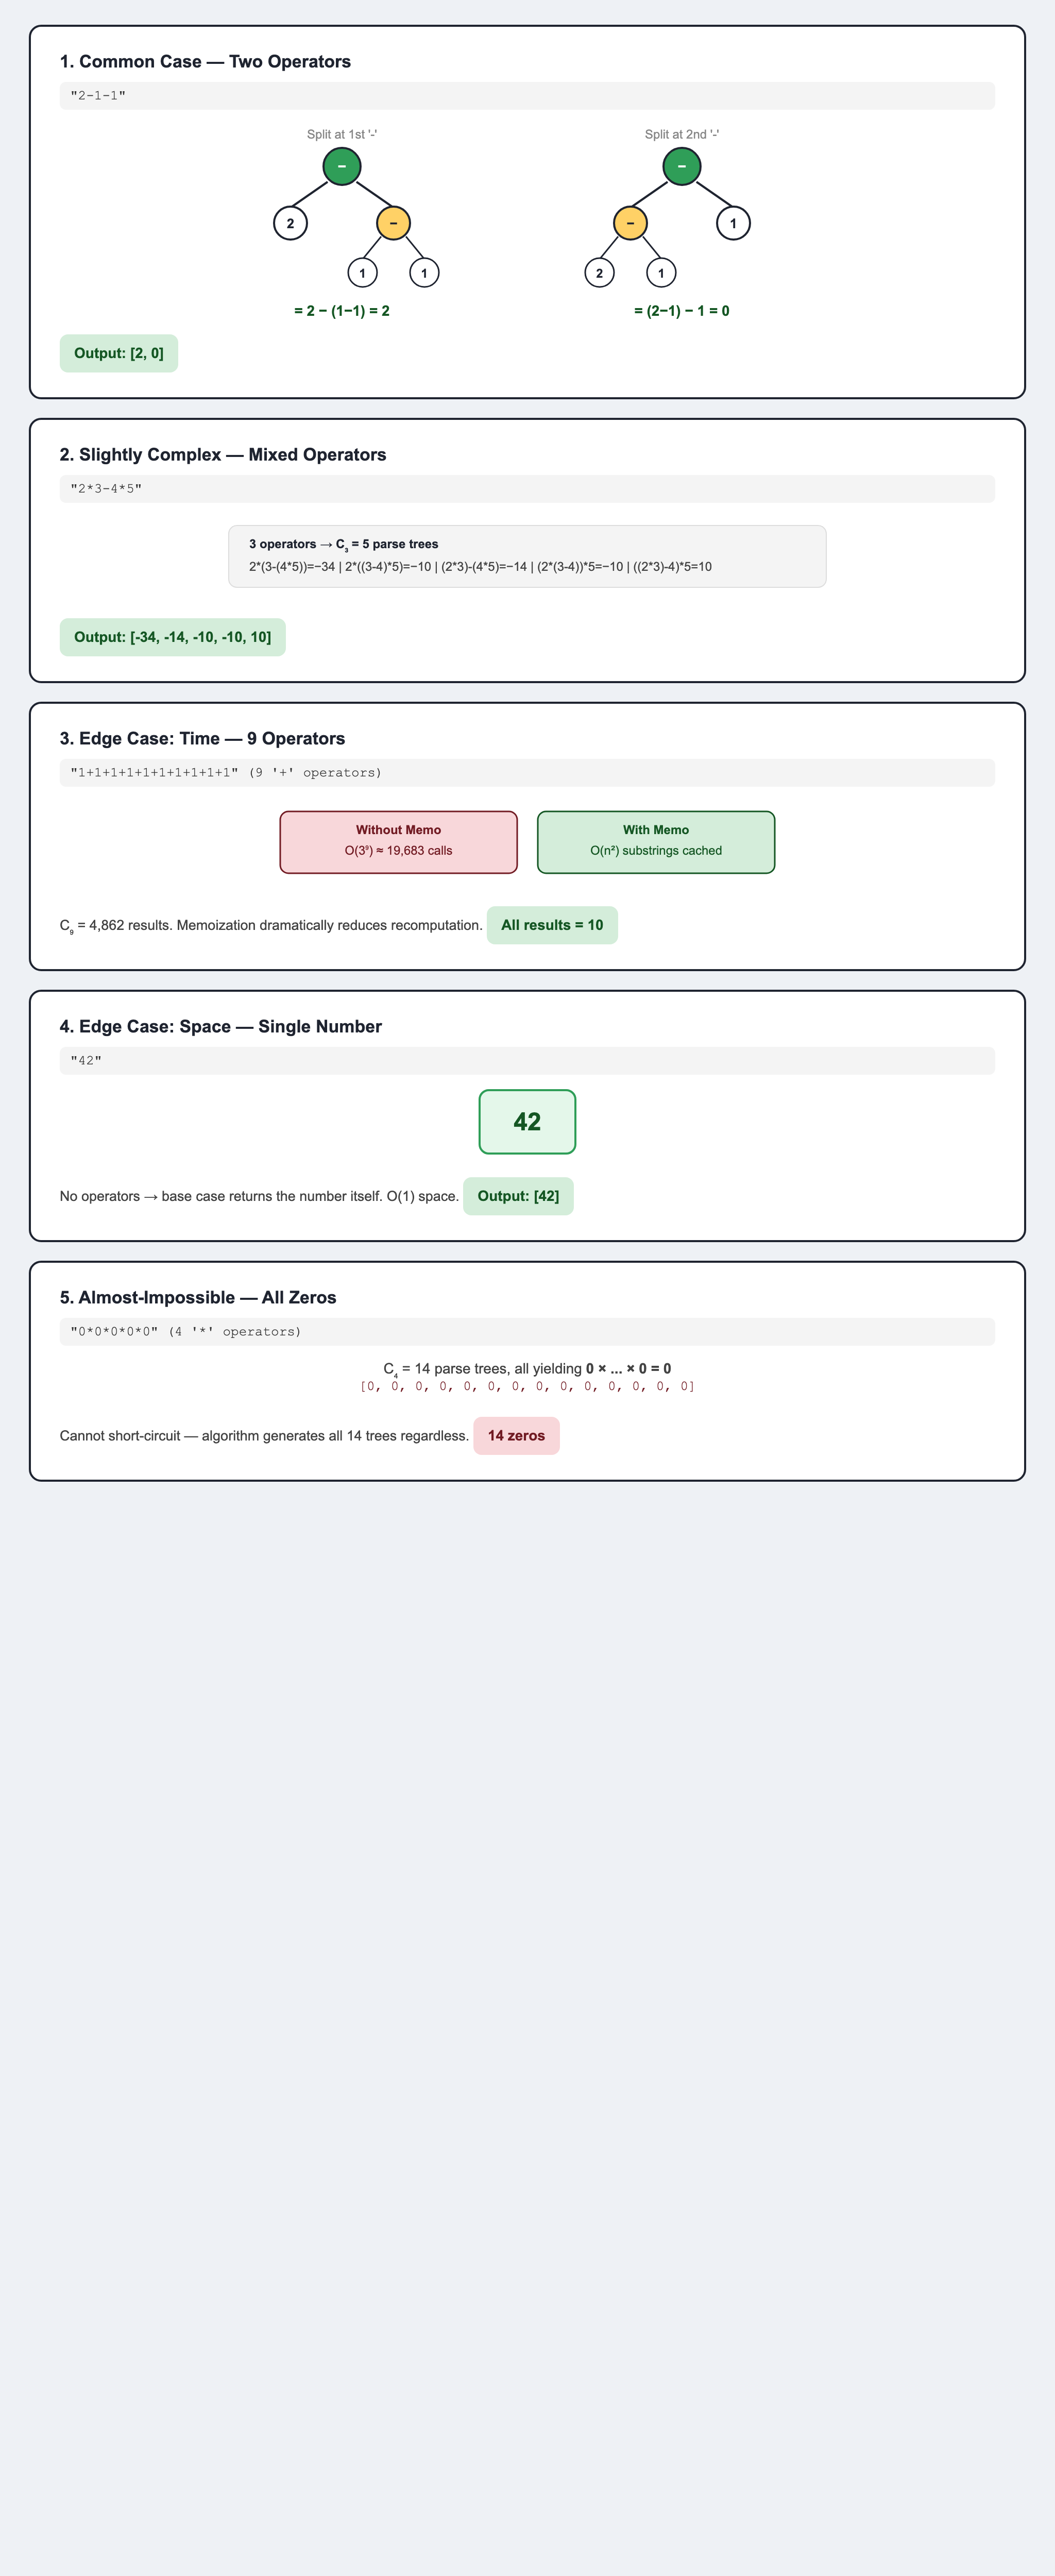